# CIL Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Inspecting and Cropping Images

First, let's list the image files in the specified directory to get an idea of the file names. Then, we'll load an example image and demonstrate how to crop it in the x-direction.

In [ ]:
import os

# Define the path to your image dataset
data_path = '/content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/cil_data'
images_folder = os.path.join(data_path, 'images')

# List some image files to verify the path
if os.path.exists(images_folder):
    image_files = [f for f in os.listdir(images_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Found {len(image_files)} image files in {images_folder}")
    if image_files:
        print("First 5 image files:")
        for i, filename in enumerate(image_files[:5]):
            print(f"- {filename}")
    else:
        print("No image files found in the 'images' folder.")
else:
    print(f"Error: The directory '{images_folder}' does not exist.")


Found 1186 image files in /content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/cil_data/images
First 5 image files:
- 1781712026.1132.jpg
- 1781712026.2166.jpg
- 1781712026.4130.jpg
- 1781712026.5264.jpg
- 1781712026.6128.jpg


Loading example image: 1781712026.1132.jpg
Original image shape: (480, 640, 3)


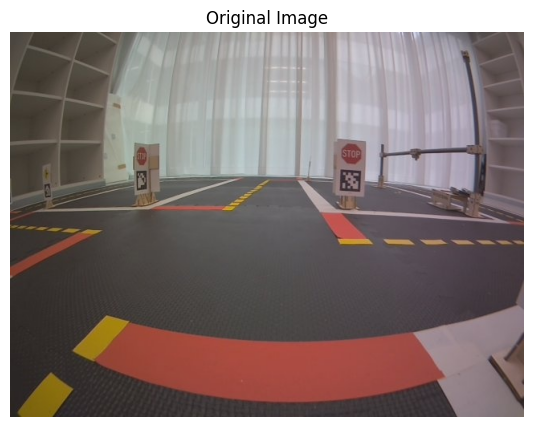

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Assuming there are image_files found in the previous cell
if 'image_files' in locals() and image_files:
    # Load an example image
    example_image_path = os.path.join(images_folder, image_files[0])
    img = mpimg.imread(example_image_path)

    print(f"Loading example image: {image_files[0]}")
    print(f"Original image shape: {img.shape}")

    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')
    plt.show()
else:
    print("No image to display. Please ensure the 'images' folder contains images.")


### Blacking out the Top Rows of the Image

Instead of cropping, you want to set the pixel values of the first `N` rows to black. This function will take an image and a number of rows to black out from the top.

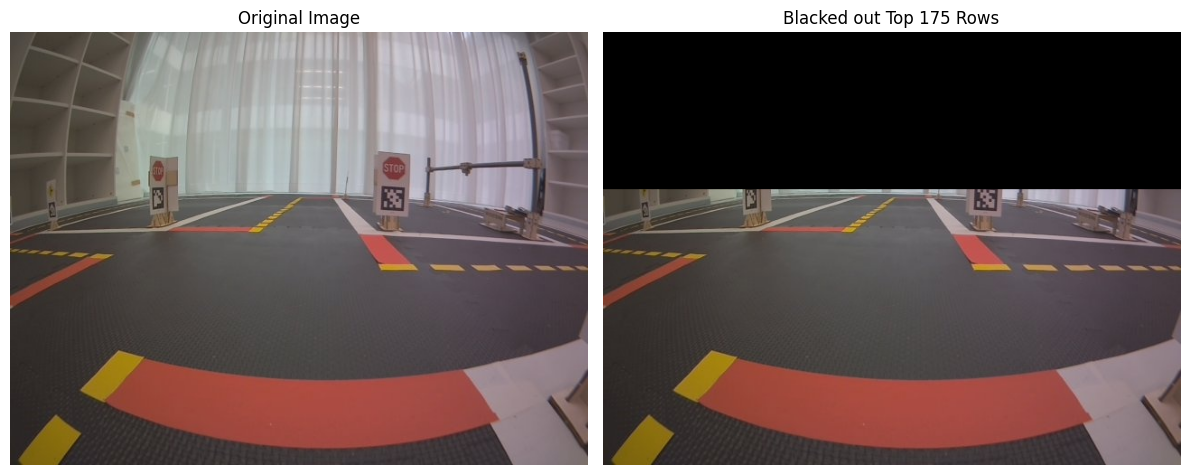

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def blackout_top_rows(image, num_rows_to_black_out):
    """
    Creates a new image where the first 'num_rows_to_black_out' rows are set to black.

    Args:
        image (numpy.ndarray): The input image (e.g., shape H, W, C).
        num_rows_to_black_out (int): The number of rows from the top to set to black.

    Returns:
        numpy.ndarray: A new image with the specified top rows blacked out.
    """
    # Create a copy to avoid modifying the original image
    modified_image = np.copy(image)

    # Set the first 'num_rows_to_black_out' rows to black (0,0,0 for RGB)
    if num_rows_to_black_out > 0 and num_rows_to_black_out < modified_image.shape[0]:
        modified_image[0:num_rows_to_black_out, :, :] = 0
    elif num_rows_to_black_out >= modified_image.shape[0]:
        # If trying to black out all or more rows than available, make the whole image black
        modified_image[:, :, :] = 0

    return modified_image

# Example usage with the loaded image (assuming 'img' is available from previous cell)
if 'img' in locals():
    # Define a single threshold for blacking out rows
    single_blackout_threshold = 175  ####  <--- change here

    plt.figure(figsize=(12, 6))

    # Display original image
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    # Display the image with the single blackout threshold
    blacked_out_img = blackout_top_rows(img, single_blackout_threshold)
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    plt.imshow(blacked_out_img)
    plt.title(f'Blacked out Top {single_blackout_threshold} Rows')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot perform blacking out. 'img' variable not found. Please ensure an image was loaded successfully.")


### Displaying 10 More Images with Top 175 Rows Blacked Out

Displaying 10 random images with the top 175 rows blacked out.


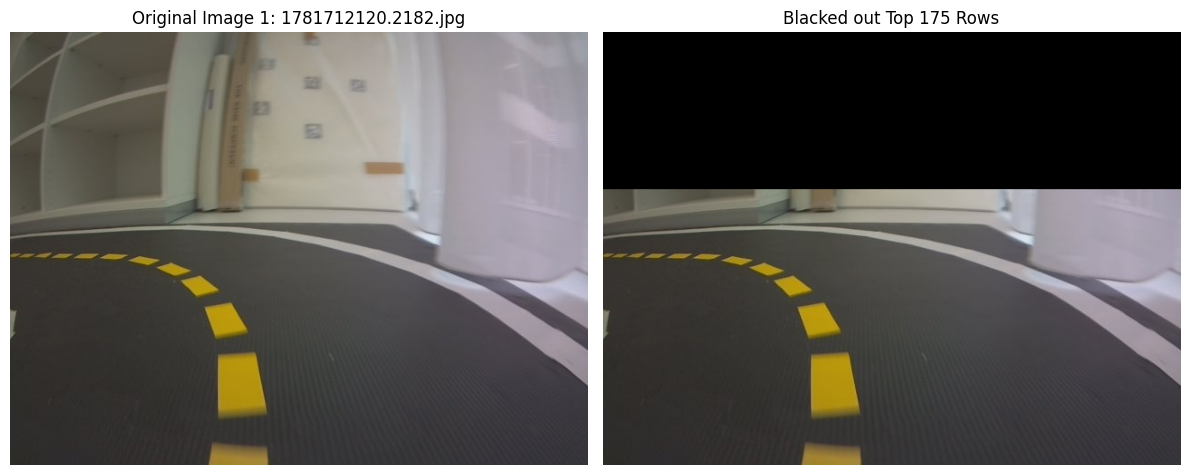

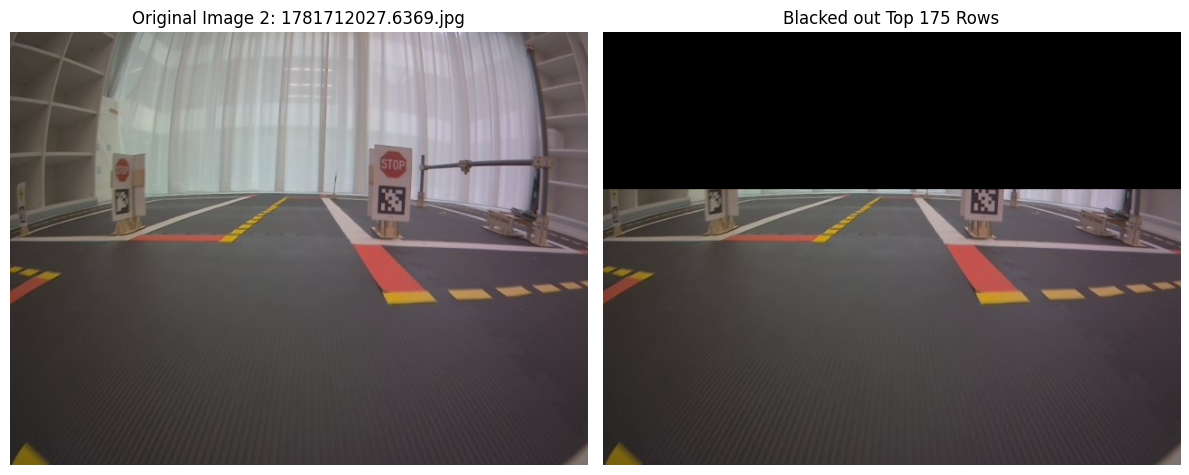

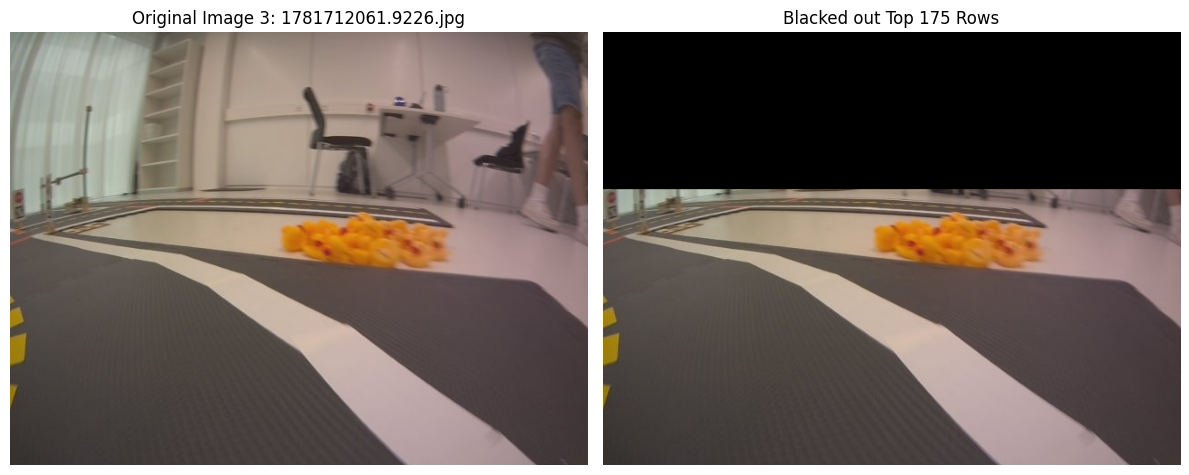

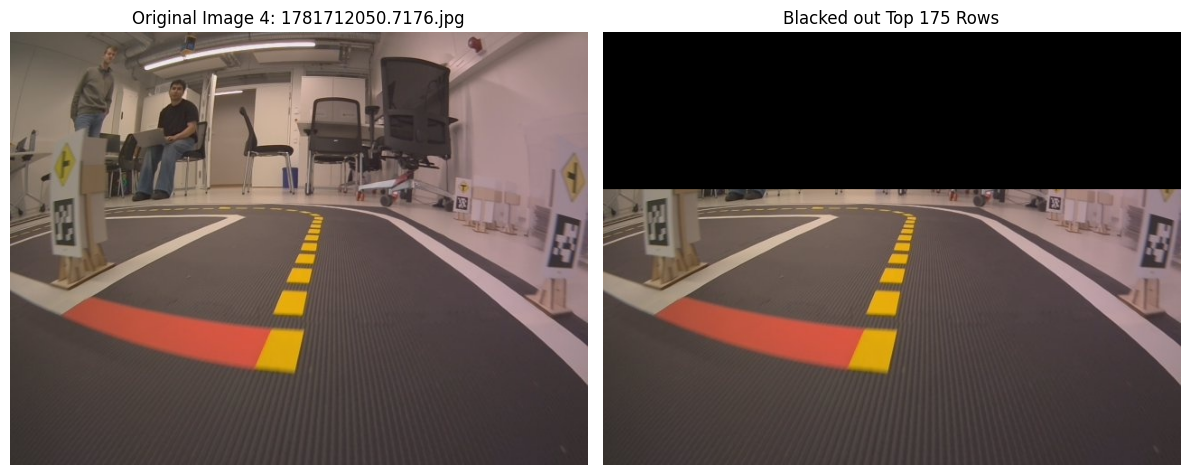

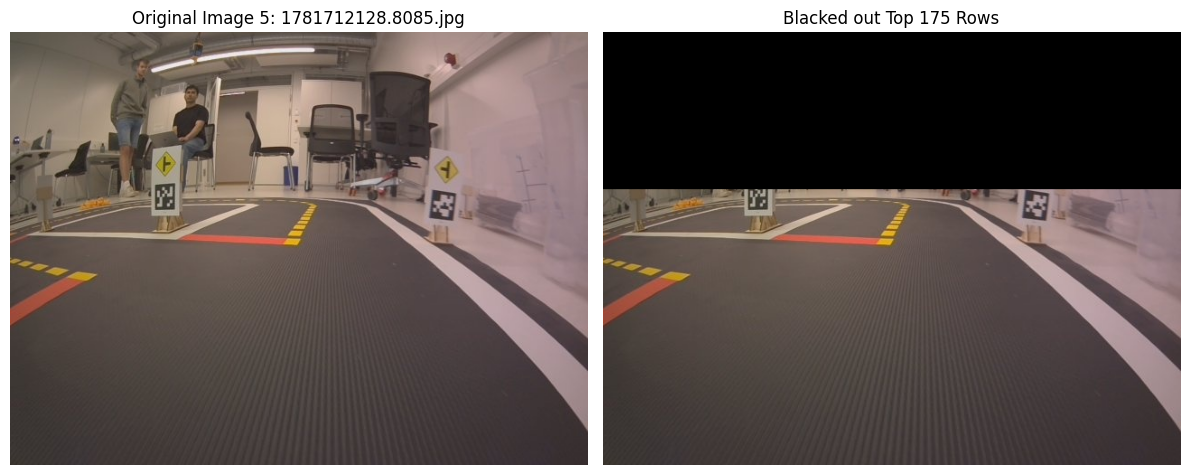

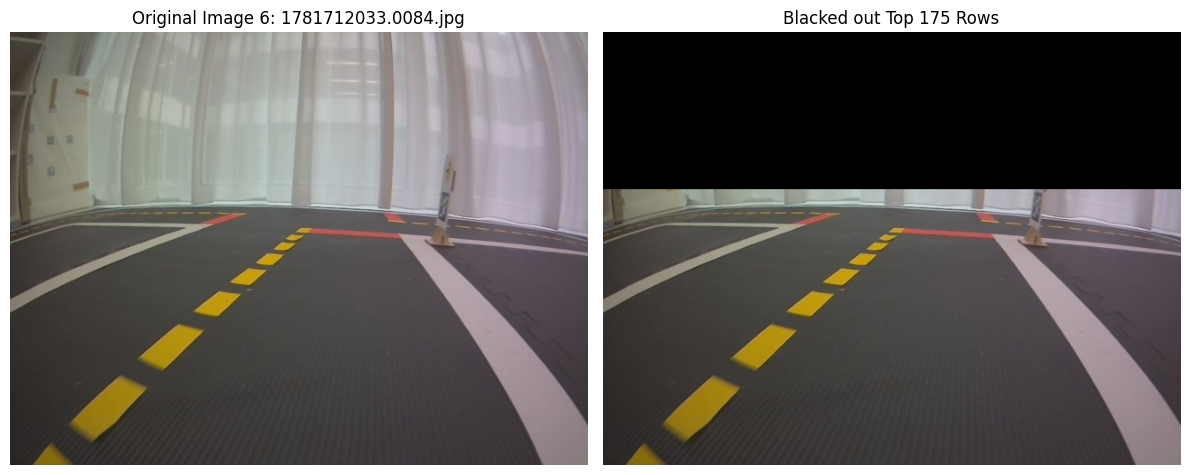

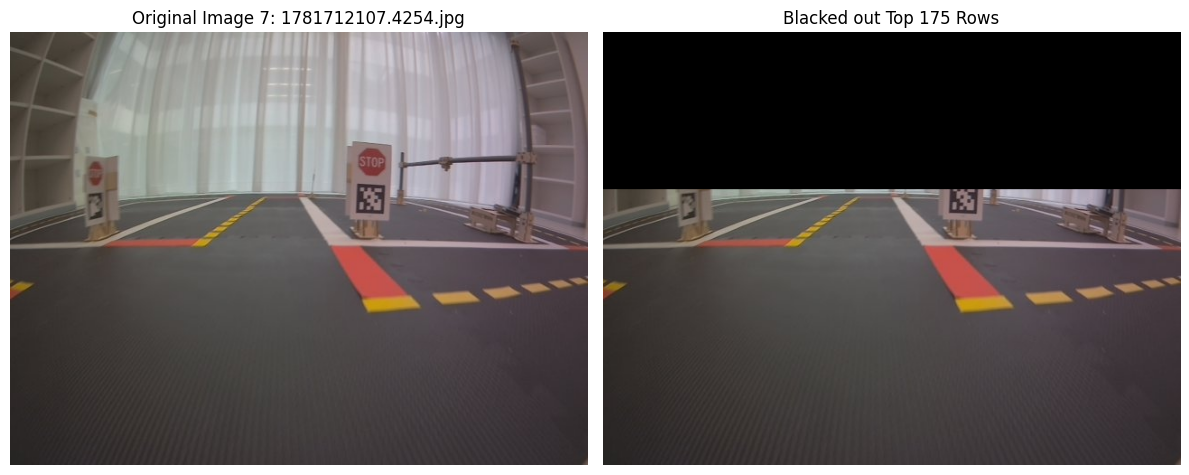

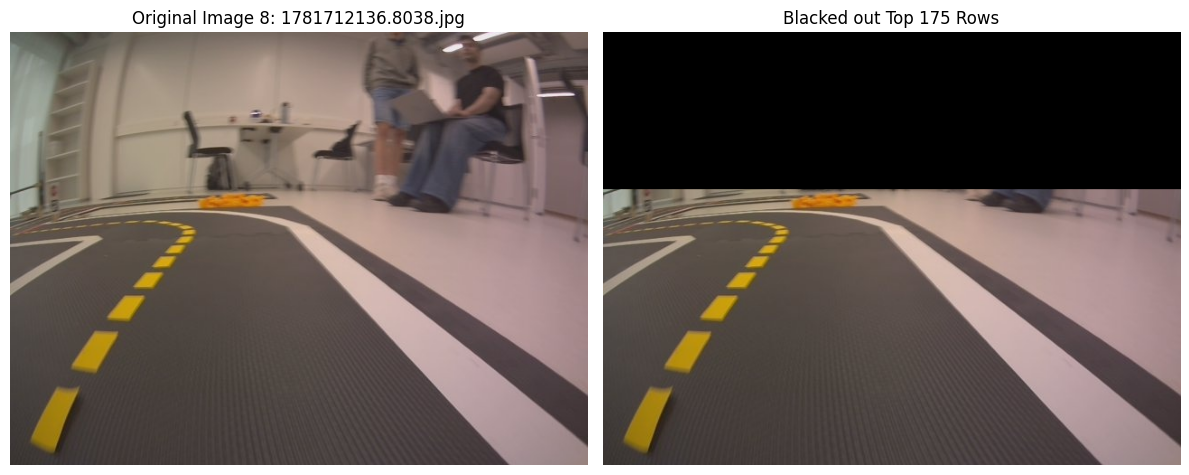

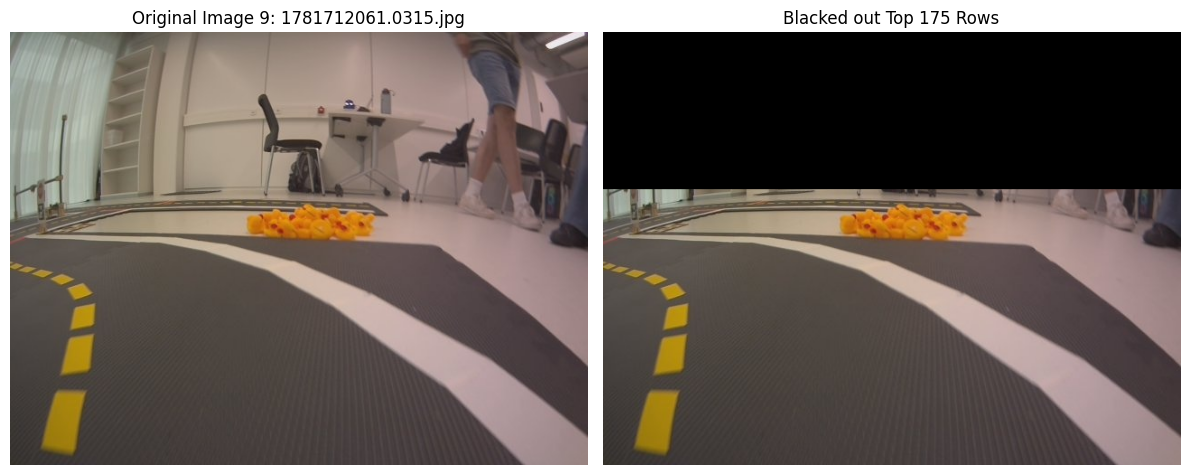

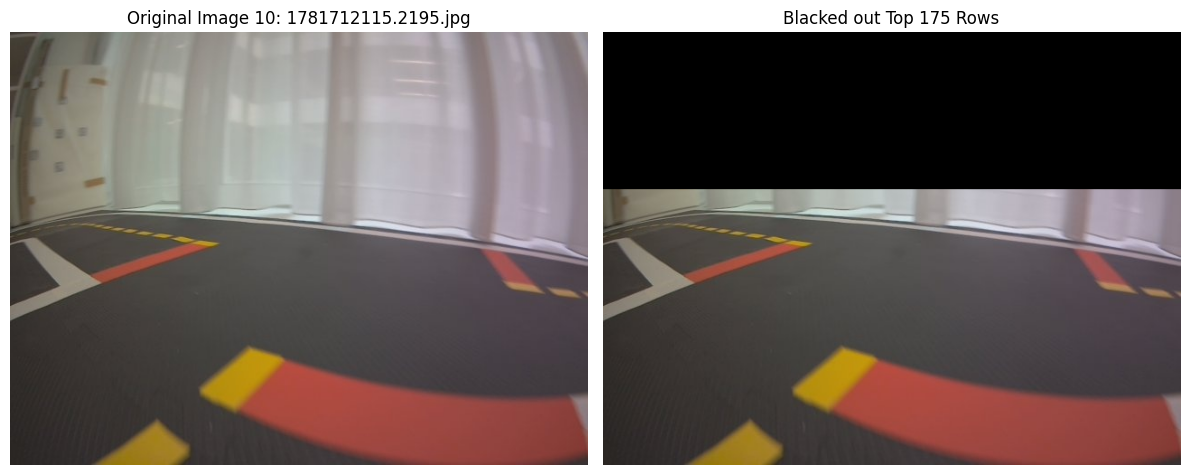

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Assuming 'image_files' (list of all image files), 'images_folder',
# and the 'blackout_top_rows' function are available from previous cells.

if 'image_files' in locals() and image_files and 'blackout_top_rows' in globals():
    num_images_to_display = 10
    blackout_threshold = 175 # User's chosen threshold

    # Select 10 random image filenames from the available image_files
    # Ensure we don't try to sample more images than available
    if len(image_files) < num_images_to_display:
        print(f"Warning: Only {len(image_files)} images available. Displaying all of them randomly.")
        random_images_to_process = random.sample(image_files, len(image_files))
    else:
        random_images_to_process = random.sample(image_files, num_images_to_display)

    if not random_images_to_process:
        print("No images found to display.")
    else:
        print(f"Displaying {len(random_images_to_process)} random images with the top {blackout_threshold} rows blacked out.")
        for i, filename in enumerate(random_images_to_process):
            current_image_path = os.path.join(images_folder, filename)
            current_img = mpimg.imread(current_image_path)

            blacked_out_current_img = blackout_top_rows(current_img, blackout_threshold)

            plt.figure(figsize=(12, 6))

            # Display original image
            plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
            plt.imshow(current_img)
            plt.title(f'Original Image {i+1}: {filename}')
            plt.axis('off')

            # Display the image with the blackout threshold
            plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
            plt.imshow(blacked_out_current_img)
            plt.title(f'Blacked out Top {blackout_threshold} Rows')
            plt.axis('off')

            plt.tight_layout()
            plt.show()
else:
    print("Required variables or function (image_files, blackout_top_rows) not found. Please ensure previous cells were run successfully.")


### Comparison: Original, Blacked Out, and Cropped (First Image)

Original image shape: (480, 640, 3)
Blacked out image shape: (480, 640, 3)
Cropped image shape (removing first 175 rows): (305, 640, 3)


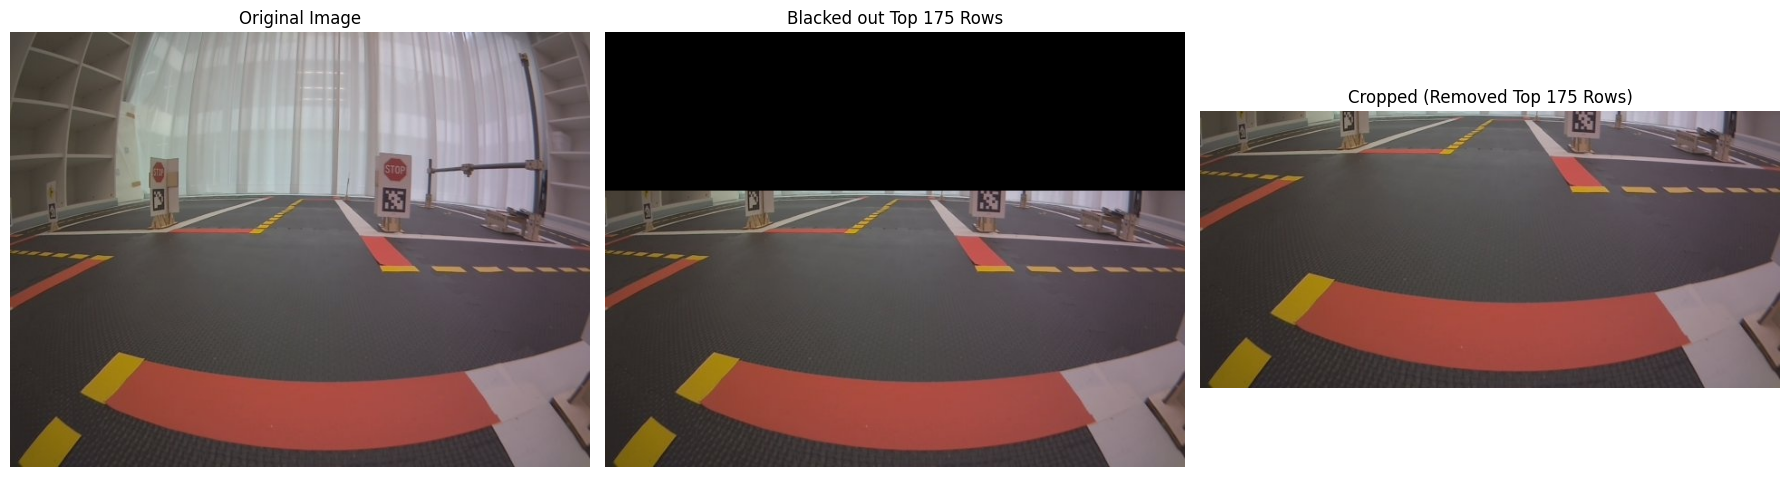

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'img' (the first loaded image) and 'blackout_top_rows' function are available
# from previous cells.

if 'img' in locals() and 'blackout_top_rows' in globals():
    threshold = 175

    # 1. Original Image (already in 'img')

    # 2. Blacked Out Image
    blacked_out_image = blackout_top_rows(img, threshold)

    # 3. Cropped Image (removing the first 'threshold' rows)
    cropped_image = img[threshold:, :, :]

    print(f"Original image shape: {img.shape}")
    print(f"Blacked out image shape: {blacked_out_image.shape}")
    print(f"Cropped image shape (removing first {threshold} rows): {cropped_image.shape}")

    plt.figure(figsize=(18, 6))

    # Plot Original
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    # Plot Blacked Out
    plt.subplot(1, 3, 2)
    plt.imshow(blacked_out_image)
    plt.title(f'Blacked out Top {threshold} Rows')
    plt.axis('off')

    # Plot Cropped
    plt.subplot(1, 3, 3)
    plt.imshow(cropped_image)
    plt.title(f'Cropped (Removed Top {threshold} Rows)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Required variables or function (img, blackout_top_rows) not found. Please ensure previous cells were run successfully.")


### Cropped Image in Black and White

Let's see how the cropped image looks when converted to grayscale (black and white).

Grayscale cropped image shape: (305, 640)


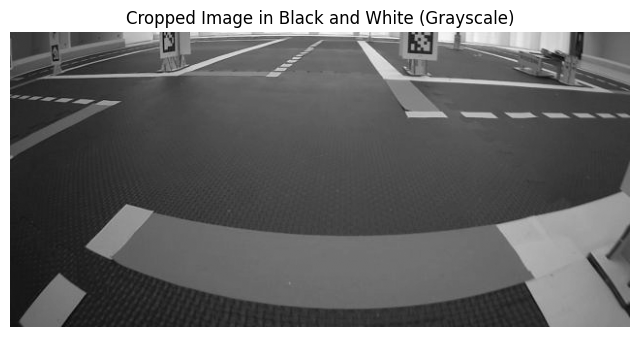

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'cropped_image' is available from the previous cell
if 'cropped_image' in locals() and cropped_image is not None:
    # Convert the cropped image to grayscale
    # A common formula for RGB to grayscale is: R*0.2989 + G*0.5870 + B*0.1140
    if cropped_image.shape[-1] == 3: # Check if it's an RGB image
        grayscale_cropped_image = np.dot(cropped_image[...,:3], [0.2989, 0.5870, 0.1140])
    else: # If it's already grayscale or has a different channel count
        grayscale_cropped_image = cropped_image # Or handle appropriately

    print(f"Grayscale cropped image shape: {grayscale_cropped_image.shape}")

    plt.figure(figsize=(8, 6))
    plt.imshow(grayscale_cropped_image, cmap='gray')
    plt.title('Cropped Image in Black and White (Grayscale)')
    plt.axis('off')
    plt.show()
else:
    print("Cannot convert to black and white. 'cropped_image' variable not found. Please ensure previous cells were run successfully.")


I decide to crop out the first 175 rows.

## Imitation Learning Model Setup

This section will prepare the environment for training an Imitation Learning model. We'll start by checking for GPU availability, then define a Convolutional Neural Network (CNN) architecture using PyTorch.

### Check for CUDA Availability

It's important to check if a CUDA-enabled GPU is available, as this significantly speeds up neural network training.

In [ ]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Current CUDA device: {torch.cuda.current_device()}")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU for computations.")


CUDA available: True
CUDA device count: 1
Current CUDA device: 0
CUDA device name: Tesla T4


### Define the CNN Model Architecture

We will now define a small CNN model in PyTorch, structured with 3 convolutional layers for downsampling and 2 fully connected layers, outputting 2 neurons. This model is designed to accept the cropped image dimensions `(305, 640, 3)`.

**Network Architecture:**
- Input: `(Batch_Size, 3, 305, 640)` (Channels, Height, Width)
- **Conv1**: `Conv2d(3, 24, kernel_size=5, stride=2)`
- **Conv2**: `Conv2d(24, 36, kernel_size=5, stride=2)`
- **Conv3**: `Conv2d(36, 48, kernel_size=5, stride=2)`
- **Flatten**: Converts the 3D feature maps into a 1D vector.
- **FC1**: `Linear(Calculated_Flattened_Size, 100)`
- **FC2**: `Linear(100, 2)` (Output neurons for steering and throttle, for example)

ReLU activation is applied after each convolutional and the first fully connected layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Input: (Batch, 3, 224, 224) after transforms.Resize

        # 3 Convolutional Layers with Downsampling (stride=2)
        # Conv1: Input 3 channels, Output 24 channels, kernel 5x5, stride 2
        # H_out = floor((224 - 5)/2) + 1 = 110
        # W_out = floor((224 - 5)/2) + 1 = 110
        self.conv1 = nn.Conv2d(3, 24, kernel_size=5, stride=2)

        # Conv2: Input 24 channels, Output 36 channels, kernel 5x5, stride=2
        # H_out = floor((110 - 5)/2) + 1 = 53
        # W_out = floor((110 - 5)/2) + 1 = 53
        self.conv2 = nn.Conv2d(24, 36, kernel_size=5, stride=2)

        # Conv3: Input 36 channels, Output 48 channels, kernel 5x5, stride=2
        # H_out = floor((53 - 5)/2) + 1 = 25
        # W_out = floor((53 - 5)/2) + 1 = 25
        self.conv3 = nn.Conv2d(36, 48, kernel_size=5, stride=2)

        # Calculate flattened size for the first fully connected layer
        # Output of conv3: (48, 25, 25)
        self.flattened_size = 48 * 25 * 25 # Corrected flattened size for 224x224 input

        # 2 Fully Connected Layers
        self.fc1 = nn.Linear(self.flattened_size, 100)
        # Output layer for regression with 2 neurons. Sigmoid added in forward pass.
        self.fc2 = nn.Linear(100, 2)

    def forward(self, x):
        # Assuming input x is (Batch, H, W, C) from the image loading
        # Permute to (Batch, C, H, W) for PyTorch Conv2d
        if x.dim() == 4 and x.shape[1] != 3: # Check if channels are not already in the second dimension
             x = x.permute(0, 3, 1, 2)
        elif x.dim() == 3 and x.shape[0] != 3: # If a single image (H, W, C)
            x = x.permute(2, 0, 1).unsqueeze(0) # Add batch dimension and permute

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        # Flatten the output for the fully connected layers
        x = x.reshape(-1, self.flattened_size) # -1 infers the batch size

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        # Apply sigmoid activation to the output
        # Note: Sigmoid squashes output to [0, 1]. Ensure your target velocities are normalized accordingly.
        x = torch.sigmoid(x)
        return x

# Instantiate the model and move it to the appropriate device
model = SimpleCNN().to(device)

# Print the model architecture
print(model)

# Optionally, test with a dummy input to verify dimensions
# The cropped_image from previous cells had shape (305, 640, 3)
# We will use this shape as input for a dummy tensor.
# Note: The dummy input should now reflect the resized dimensions (224, 224, 3)
if 'cropped_image' in locals() and cropped_image is not None:
    # Create a dummy image with the expected input shape after transforms.Resize
    dummy_img_resized = np.zeros((224, 224, 3), dtype=np.uint8) # Placeholder for actual resized image
    dummy_input = torch.from_numpy(dummy_img_resized).float().unsqueeze(0).to(device) # Add batch dim and convert to float tensor

    # The forward pass will handle the permute to (N, C, H, W)
    try:
        output = model(dummy_input)
        print(f"\nModel output shape with dummy input (after resize): {output.shape}")
    except Exception as e:
        print(f"\nError during dummy input test: {e}")
else:
    print("\n'cropped_image' not found, skipping dummy input test. Please ensure previous cells were run.")


SimpleCNN(
  (conv1): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
  (conv2): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
  (conv3): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
  (fc1): Linear(in_features=30000, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

Model output shape with dummy input (after resize): torch.Size([1, 2])


### Network Parameter Count

Let's check the total number of trainable parameters in the defined `SimpleCNN` model.

In [ ]:
if 'model' in locals():
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total number of trainable parameters in SimpleCNN: {total_params}")
else:
    print("Model 'SimpleCNN' not found. Please ensure the model definition cell was run successfully.")


Total number of trainable parameters in SimpleCNN: 3067010


## Data Preparation for Training

This section handles loading the `logs.csv` file, splitting the dataset, defining a custom PyTorch dataset, and applying necessary image transformations including cropping and augmentations.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Define the path to your data folder
data_path = '/content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/cil_data'
logs_filepath = os.path.join(data_path, 'log.csv')

# Load the logs.csv file
try:
    logs_df = pd.read_csv(logs_filepath)
    print(f"Successfully loaded logs.csv with {len(logs_df)} entries.")
    print("First 5 rows of logs_df:")
    print(logs_df.head())
except FileNotFoundError:
    print(f"Error: logs.csv not found at {logs_filepath}")
    logs_df = None

if logs_df is not None:
    # Add full path to image filenames
    logs_df['full_image_path'] = logs_df['image_filename'].apply(lambda x: os.path.join(images_folder, x))

    # Verify that image files exist (optional, but good for debugging)
    # logs_df['image_exists'] = logs_df['full_image_path'].apply(os.path.exists)
    # print(f"Number of existing image files: {logs_df['image_exists'].sum()} out of {len(logs_df)}")
    # logs_df = logs_df[logs_df['image_exists']]

    # Split the dataset into training and testing sets (80/20 ratio)
    train_df, val_df = train_test_split(logs_df, test_size=0.2, random_state=42)

    print(f"\nTraining set size: {len(train_df)}")
    print(f"Validation set size: {len(val_df)}")
else:
    train_df = pd.DataFrame()
    val_df = pd.DataFrame()


Successfully loaded logs.csv with 1186 entries.
First 5 rows of logs_df:
      timestamp       image_filename  vel_left  vel_right    intent  w  a  s  \
0  1.781712e+09  1781712026.1132.jpg       0.0        0.0  straight  0  0  0   
1  1.781712e+09  1781712026.2166.jpg       0.0        0.0  straight  0  0  0   
2  1.781712e+09  1781712026.3378.jpg       0.0        0.0  straight  0  0  0   
3  1.781712e+09  1781712026.4130.jpg       0.0        0.0  straight  0  0  0   
4  1.781712e+09  1781712026.5264.jpg       0.0        0.0  straight  0  0  0   

   d  
0  0  
1  0  
2  0  
3  0  
4  0  

Training set size: 948
Validation set size: 238


### Custom Dataset and Transformations

We need a custom PyTorch `Dataset` to load images, apply cropping and augmentations, and retrieve the corresponding target velocities. We'll also define transformations including a horizontal flip and color jitter for robustness.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2 # For more advanced image operations like color jitter

class DuckieTownDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, crop_top_rows=175):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.crop_top_rows = crop_top_rows

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.image_dir, self.dataframe.iloc[idx]['image_filename'])
        image = Image.open(img_name).convert('RGB')

        # Crop the image from the top (removing the first `crop_top_rows`)
        width, height = image.size
        image = image.crop((0, self.crop_top_rows, width, height))

        # Get target velocities
        vel_left = self.dataframe.iloc[idx]['vel_left']
        vel_right = self.dataframe.iloc[idx]['vel_right']
        target = torch.tensor([vel_left, vel_right], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, target

# Define the image transformations
# The network expects (C, H, W) and float type
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize for common CNN input
    transforms.RandomHorizontalFlip(), # Augmentation: Randomly flip the image horizontally
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Augmentation: Color jitter
    transforms.ToTensor(), # Converts PIL Image to PyTorch Tensor (H, W, C) to (C, H, W) and normalizes to [0, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset instances
train_dataset = DuckieTownDataset(dataframe=train_df, image_dir=images_folder, transform=train_transform, crop_top_rows=175)
val_dataset = DuckieTownDataset(dataframe=val_df, image_dir=images_folder, transform=val_transform, crop_top_rows=175)

# Define batch size
batch_size = 64

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\nTrain DataLoader created with {len(train_loader)} batches.")
print(f"Validation DataLoader created with {len(val_loader)} batches.")

# Test a sample from the DataLoader
if train_loader:
    first_batch_images, first_batch_targets = next(iter(train_loader))
    print(f"\nSample batch images shape: {first_batch_images.shape}") # Expected: (batch_size, C, H, W)
    print(f"Sample batch targets shape: {first_batch_targets.shape}") # Expected: (batch_size, 2)
    print(f"Sample batch targets (first 5):\n{first_batch_targets[:5]}")
else:
    print("Train DataLoader is empty.")



Train DataLoader created with 15 batches.
Validation DataLoader created with 4 batches.

Sample batch images shape: torch.Size([64, 3, 224, 224])
Sample batch targets shape: torch.Size([64, 2])
Sample batch targets (first 5):
tensor([[0.0000, 0.0000],
        [0.2155, 0.2504],
        [0.2155, 0.2504],
        [0.1508, 0.4257],
        [0.2155, 0.2504]])


## Training Loop

Now we'll define the training and validation functions and run the training process. We will use an appropriate loss function and optimizer for this regression task.

### Enhancements to the Training Loop

I've enhanced the training process to include the following:

1.  **Initial Performance Measurement**: Before the training officially begins, the model's performance (loss) on both the training and validation sets will be evaluated. This provides a baseline to understand the impact of training.
2.  **Epoch-wise Time Estimation**: Each epoch's training and validation time will be measured and reported, giving an estimate of the training duration.
3.  **Model Saving**: The model with the lowest validation loss encountered during training will be saved as `best_model.pth`. Additionally, the model's state after the final epoch will be saved as `last_model.pth`.

In [ ]:
import os

# Define directory for saving models
model_save_dir = os.path.join(data_path, 'models') # Using data_path defined earlier

# Create the directory if it doesn't exist
if not os.path.exists(model_save_dir):
    os.makedirs(model_save_dir)
    print(f"Created model saving directory: {model_save_dir}")
else:
    print(f"Model saving directory already exists: {model_save_dir}")

Created model saving directory: /content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/cil_data/models


Starting training...
Calculating initial performance...
Initial Train Loss: 0.0058, Initial Val Loss: 0.0055
Epoch 1/10, Train Loss: 0.0068, Val Loss: 0.0061, Time: 13.06s
-> Saved best model at epoch 1 with Val Loss: 0.0061
Epoch 2/10, Train Loss: 0.0051, Val Loss: 0.0058, Time: 13.27s
-> Saved best model at epoch 2 with Val Loss: 0.0058
Epoch 3/10, Train Loss: 0.0046, Val Loss: 0.0051, Time: 14.60s
-> Saved best model at epoch 3 with Val Loss: 0.0051
Epoch 4/10, Train Loss: 0.0042, Val Loss: 0.0051, Time: 13.53s
-> Saved best model at epoch 4 with Val Loss: 0.0051
Epoch 5/10, Train Loss: 0.0041, Val Loss: 0.0052, Time: 13.03s
Epoch 6/10, Train Loss: 0.0041, Val Loss: 0.0053, Time: 12.31s
Epoch 7/10, Train Loss: 0.0037, Val Loss: 0.0049, Time: 12.78s
-> Saved best model at epoch 7 with Val Loss: 0.0049
Epoch 8/10, Train Loss: 0.0037, Val Loss: 0.0047, Time: 13.51s
-> Saved best model at epoch 8 with Val Loss: 0.0047
Epoch 9/10, Train Loss: 0.0037, Val Loss: 0.0047, Time: 13.42s
-> Sav

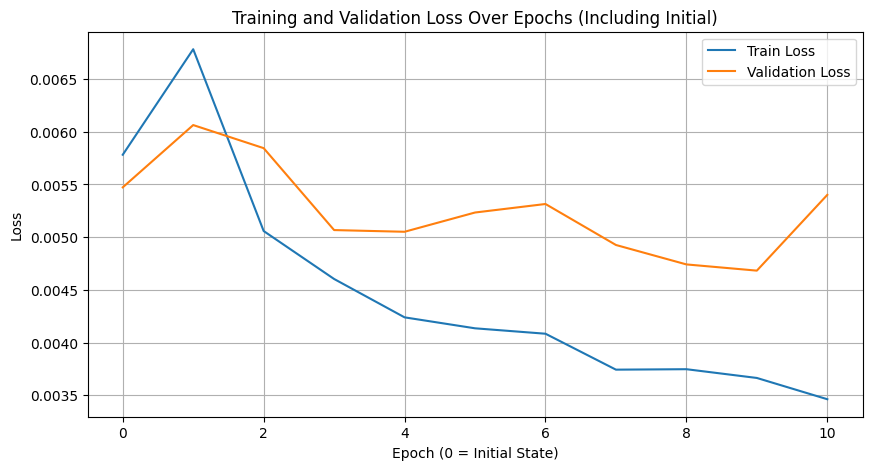

In [ ]:
import torch.optim as optim
import time

# Define Loss Function and Optimizer
criterion = nn.MSELoss() # Mean Squared Error Loss for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10 # You can adjust the number of epochs

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(dataloader):
        inputs = inputs.to(device) # Move inputs to GPU if available
        targets = targets.to(device) # Move targets to GPU if available

        optimizer.zero_grad() # Zero the parameter gradients

        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, targets) # Calculate loss

        loss.backward() # Backward pass
        optimizer.step() # Optimize weights

        running_loss += loss.item() * inputs.size(0) # Accumulate batch loss
    return running_loss / len(dataloader.dataset)

def validate_epoch(model, dataloader, criterion, device):
    model.eval() # Set the model to evaluation mode
    running_loss = 0.0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
    return running_loss / len(dataloader.dataset)

print("Starting training...")

history = {'train_loss': [], 'val_loss': []}

# --- Initial Performance Measurement ---
print("Calculating initial performance...")
initial_train_loss = validate_epoch(model, train_loader, criterion, device)
initial_val_loss = validate_epoch(model, val_loader, criterion, device)

history['train_loss'].append(initial_train_loss)
history['val_loss'].append(initial_val_loss)
print(f'Initial Train Loss: {initial_train_loss:.4f}, Initial Val Loss: {initial_val_loss:.4f}')

# --- Model Saving Setup ---
best_val_loss = float('inf')
best_epoch = -1
best_model_path = os.path.join(model_save_dir, 'best_model.pth')
last_model_path = os.path.join(model_save_dir, 'last_model.pth')

# --- Training Loop ---
for epoch in range(num_epochs):
    epoch_start_time = time.time()

    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_epoch(model, val_loader, criterion, device)

    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Time: {epoch_duration:.2f}s')

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), best_model_path)
        print(f'-> Saved best model at epoch {best_epoch} with Val Loss: {best_val_loss:.4f}')

print("Training finished.")

# Save the last model
torch.save(model.state_dict(), last_model_path)
print(f"Last model saved to {last_model_path}")

print(f"Best model found at epoch {best_epoch} with Validation Loss: {best_val_loss:.4f}")

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(len(history['train_loss'])), history['train_loss'], label='Train Loss')
plt.plot(range(len(history['val_loss'])), history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs (Including Initial)')
plt.xlabel('Epoch (0 = Initial State)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Testing the Best Model

Now that the training is complete and the best model has been saved, let's load it and test its performance on a few example images from the validation set. We will visualize the input image and compare the model's predicted velocities with the actual ground truth velocities.

In [ ]:
import torch

# Load the best model
loaded_model = SimpleCNN().to(device) # Re-initialize model architecture
loaded_model.load_state_dict(torch.load(best_model_path)) # Load the saved weights
loaded_model.eval() # Set to evaluation mode

print(f"Loaded best model from: {best_model_path}")

Loaded best model from: /content/drive/MyDrive/ColabNotebooks/MasterML/Duckietown/cil_data/models/best_model.pth


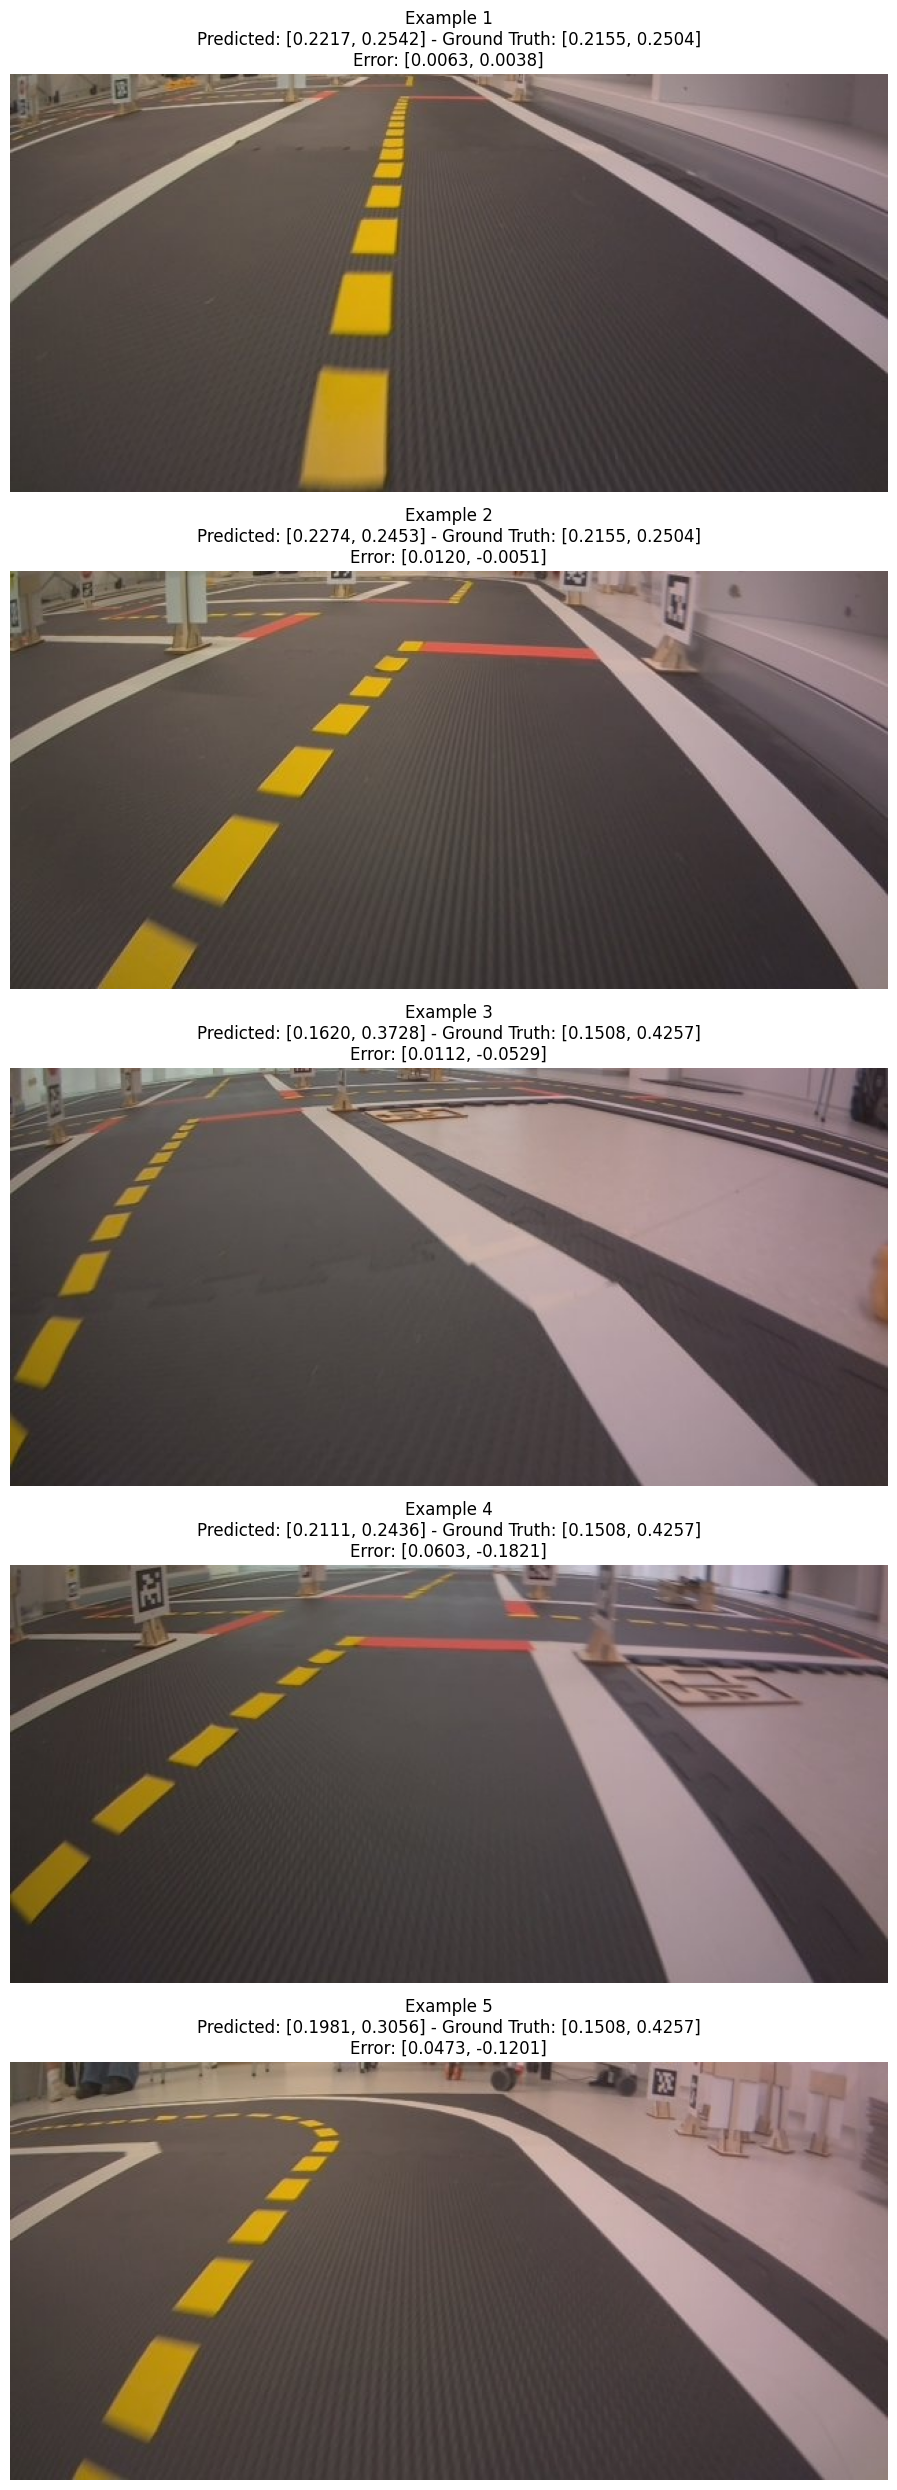

In [ ]:
import matplotlib.pyplot as plt
from torchvision import transforms

# Get a few example samples from the validation dataset
num_examples = 5
example_indices = np.random.choice(len(val_dataset), num_examples, replace=False)

plt.figure(figsize=(15, 5 * num_examples))

for i, idx in enumerate(example_indices):
    # Get original image and target from dataset (before ToTensor and Normalize)
    # We need to recreate the image from the dataframe for display purposes
    original_img_path = os.path.join(images_folder, val_df.iloc[idx]['image_filename'])
    original_image = Image.open(original_img_path).convert('RGB')
    # Apply the same cropping as in the dataset
    width, height = original_image.size
    display_image = original_image.crop((0, train_dataset.crop_top_rows, width, height))

    # Get the image and target as processed by the validation transform for model input
    model_input_image, ground_truth_target = val_dataset[idx]

    # Add a batch dimension and move to device
    model_input_image = model_input_image.unsqueeze(0).to(device)

    # Make prediction
    with torch.no_grad():
        prediction = loaded_model(model_input_image)

    # Move prediction and ground truth to CPU for display
    prediction = prediction.squeeze(0).cpu().numpy()
    ground_truth_target = ground_truth_target.cpu().numpy()

    # Calculate the error
    error = prediction - ground_truth_target

    plt.subplot(num_examples, 1, i + 1)
    plt.imshow(display_image) # Display the cropped PIL image
    plt.title(f"Example {i+1}\nPredicted: [{prediction[0]:.4f}, {prediction[1]:.4f}] - Ground Truth: [{ground_truth_target[0]:.4f}, {ground_truth_target[1]:.4f}]\nError: [{error[0]:.4f}, {error[1]:.4f}]")
    plt.axis('off')

plt.tight_layout()
plt.show()